In [78]:
# The goal of this project is to look at land temperature and the urban spawl of Huntsville, AL
# First I need to add the data by creating a function that will read the raster data I add and clip to Huntsville
# Second I need to take that data and compare it to one another
# Third I need to compare the urbanization of huntsville from Aug 2019-Aug 2024. 

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
from rasterio.plot import show
import geopandas as gpd
from rasterio.mask import mask
import glob
import re

In [52]:
boundary_path = r"C:\Users\alayn\OneDrive\Masters_UAH\AES_508\Final\HuntsvilleCityLimits\Boundary_City_Huntsville_poly.shp"
LS09_data_folder = "Landsat_Data/"

In [120]:
b10_tif_files = glob.glob(LS09_data_folder + "*B10.TIF")
b10_tif_files

['Landsat_Data\\LC08_L2SP_020036_20190815_20200827_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC08_L2SP_020036_20230826_20230905_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC08_L2SP_020036_20240828_20240905_02_T1_ST_B10.TIF',
 'Landsat_Data\\LC09_L2SP_020036_20220831_20230331_02_T1_ST_B10.TIF']

In [121]:
# temp = os.path.join(LS09_data_folder, "LC08_L2SP_020036_20190815_20200827_02_T1_ST_B10.TIF")

In [122]:
city = gpd.read_file(boundary_path)

In [123]:
# def clip_to_city(tif_path, boundary):
#     # clip the tif to the boundary
#     with rasterio.open(tif_path) as src:
#         # reproject 
#         boundary = boundary.to_crs(src.crs)
    
#         clipped, clipped_transform = mask(src, shapes=boundary.geometry, crop=True, nodata=0)
#         clipped_metadata = src.meta.copy()

#         raw = src.read(1).astype("float32")
#         profile = src.profile
#         nodata = src.nodata

#     raw = np.where(raw == nodata, np.nan, raw)
#     kelvin = raw * 0.00341802 + 149.0
#     celsius = kelvin - 273.15

#     fig, ax = plt.subplots(figsize = (10, 10))
#     show(clipped, transform=clipped_transform, ax=ax, title=tif_path.split("\\")[-1])

In [124]:
def clip_to_city(tif_path, boundary):
    # clip the tif to the boundary
    with rasterio.open(tif_path) as src:
        # reproject 
        boundary = boundary.to_crs(src.crs)
    
        clipped, clipped_transform = mask(src, shapes=boundary.geometry, crop=True, nodata=0)

    return clipped[0], clipped_transform

    # fig, ax = plt.subplots(figsize = (10, 10))
    # show(clipped, transform=clipped_transform, ax=ax, title=tif_path.split("\\")[-1])

In [125]:
def extract_year(path):
    # google helped me with this
    match = re.search(r'_(\d{4})\d{4}_', os.path.basename(path))
    return int(match.group(1))
    
def get_path(b10_path, desired_band):
    return re.sub(r'ST_B10\.TIF$', f'SR_{desired_band}.TIF', b10_path)

In [126]:
def compute_ndvi(b4, b5):
    # to fix divide by 0 errors
    b4 = np.where(b4 == 0, np.nan, b4)
    b5 = np.where(b5 == 0, np.nan, b5)
    denom = (b5 + b4)
    return np.where(denom != 0, (b5 - b4) / denom, np.nan)

In [129]:
years_data = {}

for b10_path in b10_tif_files:
    year = extract_year(b10_path)
    b4_path = get_path(b10_path, "B4")
    b5_path = get_path(b10_path, "B5")
    lst, transform = clip_to_city(b10_path, city)
    b4, _ = clip_to_city(b4_path, city)
    b5, _ = clip_to_city(b5_path, city)
    ndvi = compute_ndvi(b4, b5)

    # plot the ndvi
    # fig, ax = plt.subplots(figsize=(8, 8))
    # im = ax.imshow(ndvi)

    years_data[year] = {"ndvi":ndvi, "lst":lst, "transform": transform}

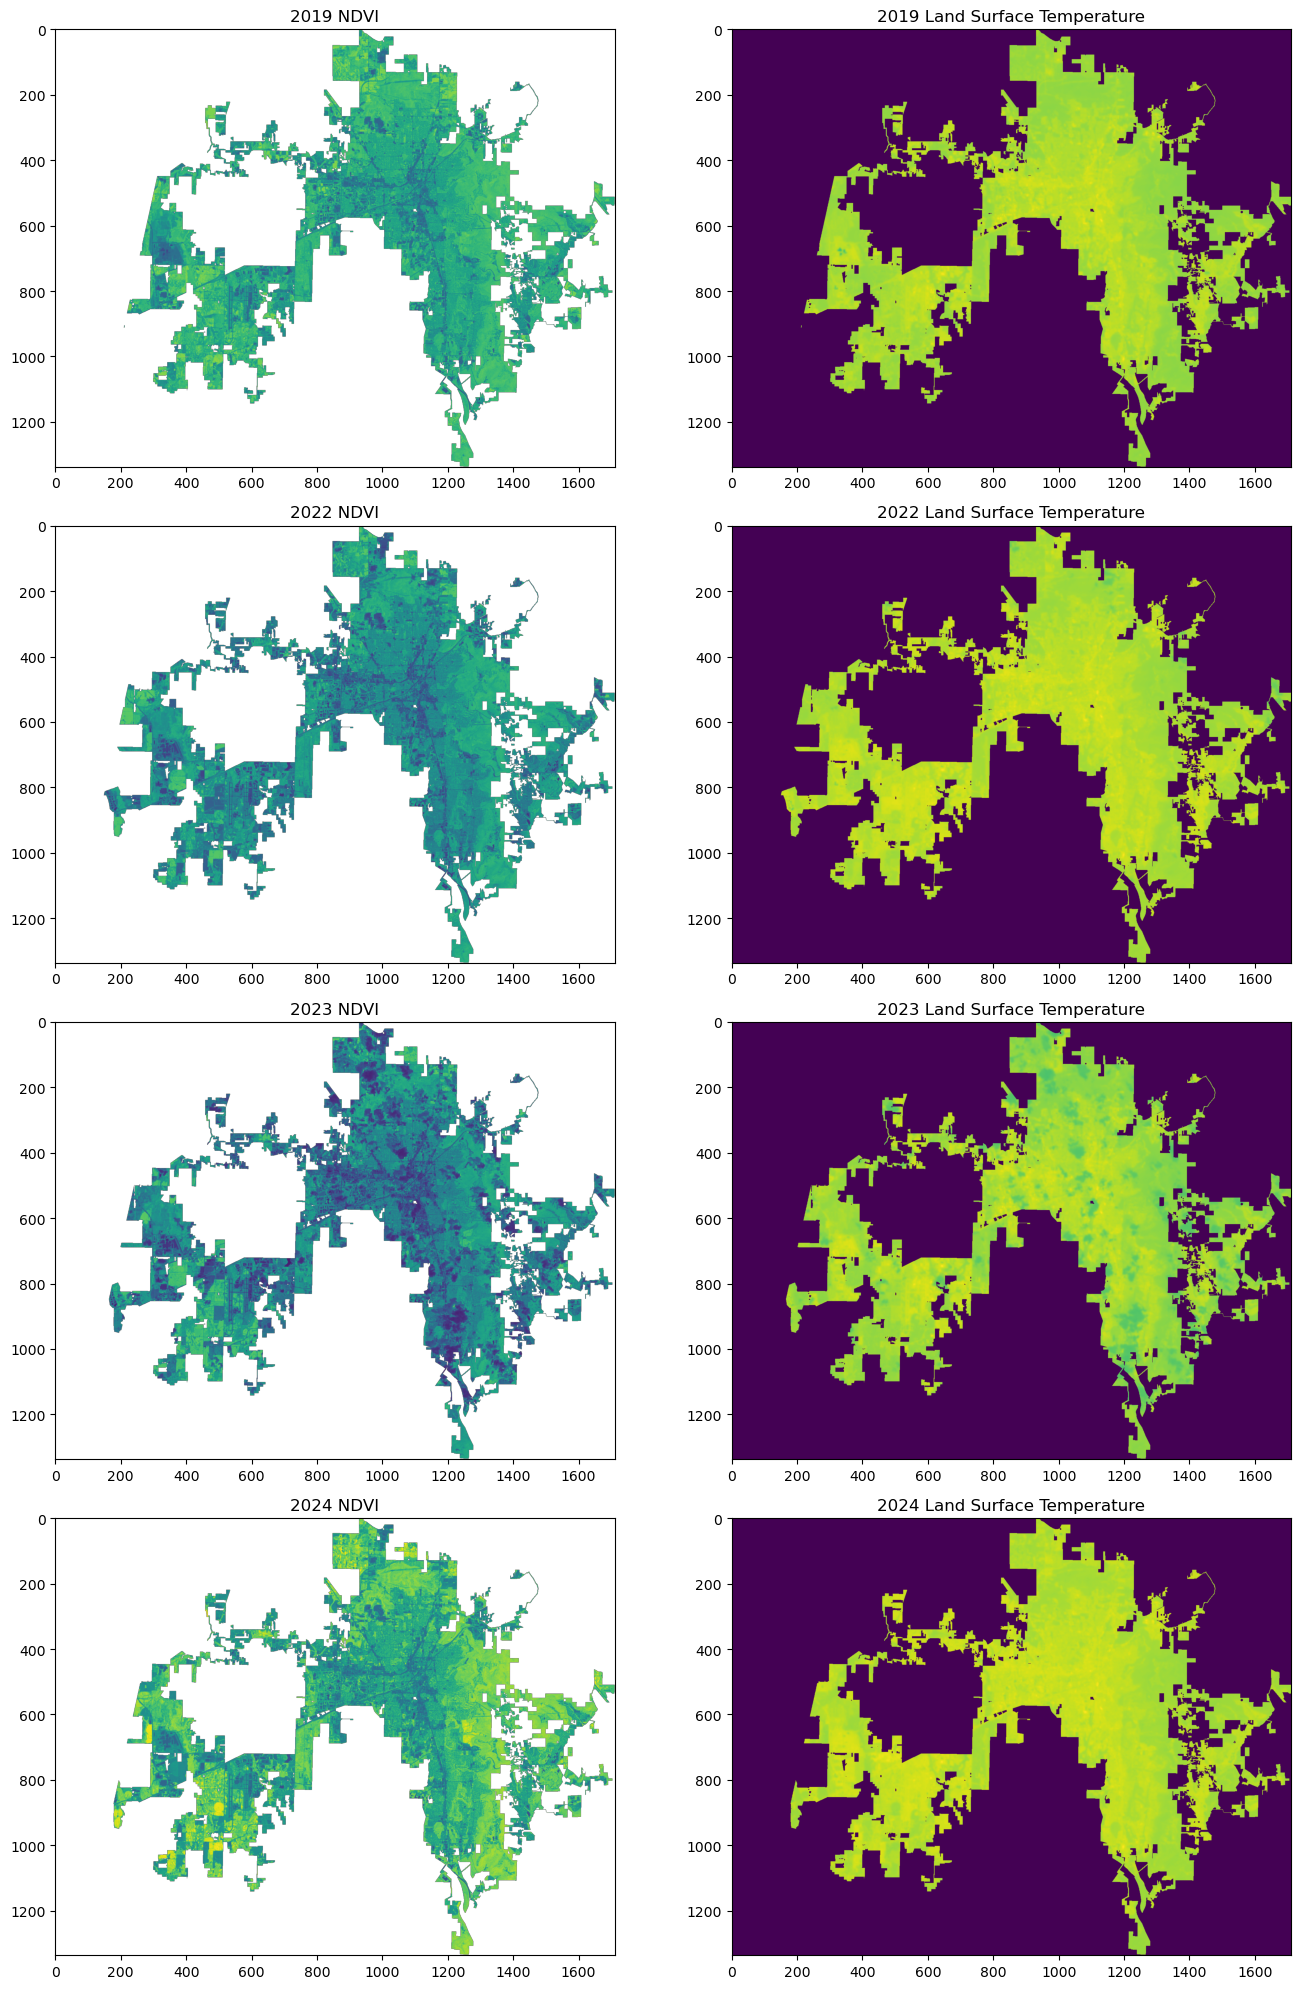

In [138]:
sorted_years = sorted(years_data.keys())
n = len(sorted_years)

# Plot each year
fig, ax = plt.subplots(n, 2, figsize=(14,5*n))

for row, year in enumerate(sorted_years):
    data = years_data[year]
    ax_ndvi = ax[row][0]
    im1 = ax_ndvi.imshow(data["ndvi"])
    ax_ndvi.set_title(f"{year} NDVI")

    ax_lst = ax[row][1]
    im2 = ax_lst.imshow(data["lst"])
    ax_lst.set_title(f"{year} Land Surface Temperature")

plt.tight_layout()
plt.show()